<div align = "right">
27 / 05 / 26
<div style = "height: 20px;"></div>
<span style = "color:orange"> <strong>Reconocimiento de Patrones </strong></span>
<style>div[align = "right"]{font-family: 'Montserrat', sans-serif;}</style></div>

<h1 style = "color: orange"><strong> Práctica 5: Agrupamiento y clasificación</strong></h1>

In [21]:
import pandas as pd
import cv2 
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, Subset

## **Implementación de BoW**

#### 1a. Descarga de dataset

Seleccioné el conjunto de datos ``airplane``. 

In [10]:
transform = transforms.Compose([
    transforms.Resize(128, interpolation = transforms.InterpolationMode.LANCZOS),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Descarga
dataset = torchvision.datasets.CIFAR10(
    root = './data',
    train = True,
    download = True,
    transform = transform
)

# Filtrar la clase airplane
airplane_indices = [i for i, label in enumerate(dataset.targets) if label == 0]
airplane_dataset = Subset(dataset, airplane_indices)

print(f'Total imágenes de airplane: {len(airplane_dataset)}')

loader = DataLoader(airplane_dataset, batch_size = 32, shuffle = True)

Total imágenes de airplane: 5000


In [11]:
images, labels = next(iter(loader))
print(f"Shape del batch: {images.shape}") 
print(f'Todas son airplane (0): {labels.unique()}')

Shape del batch: torch.Size([32, 3, 128, 128])
Todas son airplane (0): tensor([0])


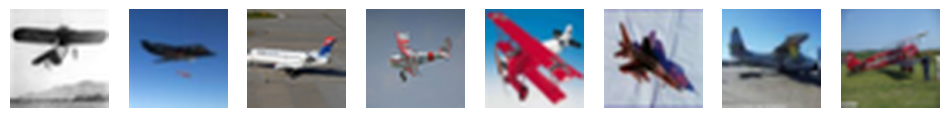

In [19]:
fig, axes = plt.subplots(1, 8, figsize = (12, 2))

for i, ax in enumerate(axes):

    img = images[i].permute(1, 2, 0) * 0.5 + 0.5
    ax.imshow(img.numpy(), interpolation = 'bilinear')
    ax.axis('off')
plt.show()

#### 1b. Descriptores SIFT

#### 1c. $k$-means con $k$ clusters para obtener el vocabulario

In [25]:
for img in images:

    # Convertir a escala de grises
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Crear un objeto SIFT y detectar los keypoints
    sift = cv.SIFT_create()
    kp = sift.detect(gray, None)

    # Dibujar los keypoints en la imagen original
    img = cv2.drawKeypoints(gray, kp, img, flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    plt.imshow(img)

error: OpenCV(4.13.0) :-1: error: (-5:Bad argument) in function 'cvtColor'
> Overload resolution failed:
>  - src is not a numpy array, neither a scalar
>  - Expected Ptr<cv::UMat> for argument 'src'


#### 1d. Construir histogramas de palabras (mostrar 5)

#### 1e. Dividir el conjunto de entrenamiento y prueba en 80-20.

#### 1f. Entrenar un ``SVM`` lineal con los histogramas de entrenamiento usanto grid search para los hiperparámetros.

#### 1g. Predecir las etiquetas del conjunto de prueba y calcular la exactitud.

#### 1h. Matriz de confusión.

---
### 2. Evaluación y comparación

#### 2a. Variar las palabras visuales $(k = 50, 200, 500)$

#### 2b. Cambiar la ``SVM`` por un Random Forest

#### 2c. Agregar validación cruzada con cinco particiones e informar medidas de tendencia central de la exactitud.

---
### 3 Repetir el proceso con otra base de datos (opcional).

---
### 4. Preguntas

¿Por qué es necesario normalizar los histogramas?

¿Qué ocurre si $k$ es demasiado pequeño o si es demasiado grande?

¿Podría utilizarse este método para detección de objetos en lugar de clasificación?